In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


--- Descriptive Statistics ---
Games with valid playtime data : 7,896
Median playtime                : 360 minutes
Median reviews                 : 2,258

--- Spearman Correlation Test (one-tailed) ---
ρ                : 0.4919
P-value (1-tail) : 0.000000

Result: REJECT H0 — Significant positive correlation between playtime and popularity.


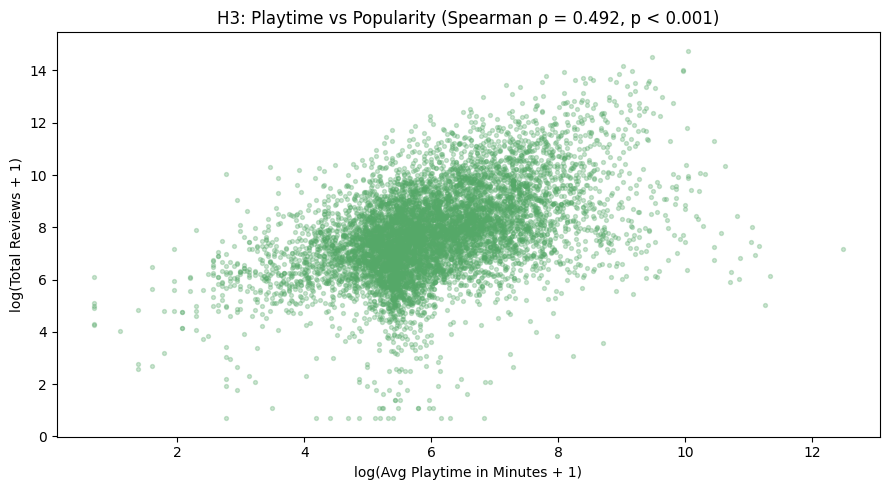

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 3: Playtime vs Popularity
#
# H0: There is no significant correlation between average
#     playtime and popularity.
# H1: Games with longer playtime are more popular
#     (positive correlation).
#
# Test: Spearman Rank Correlation (non-parametric, one-tailed)
# ============================================================

spy_df = df.dropna(subset=["avg_playtime_minutes"])
spy_df = spy_df[spy_df["avg_playtime_minutes"] > 0]

print("--- Descriptive Statistics ---")
print(f"Games with valid playtime data : {spy_df.shape[0]:,}")
print(f"Median playtime                : {spy_df['avg_playtime_minutes'].median():,.0f} minutes")
print(f"Median reviews                 : {spy_df['total_reviews'].median():,.0f}")

corr, p_two = stats.spearmanr(spy_df["avg_playtime_minutes"], spy_df["total_reviews"])
p_one = p_two / 2 if corr > 0 else 1 - p_two / 2

print("\n--- Spearman Correlation Test (one-tailed) ---")
print(f"ρ                : {corr:.4f}")
print(f"P-value (1-tail) : {p_one:.6f}")

if p_one < 0.05 and corr > 0:
    print("\nResult: REJECT H0 — Significant positive correlation between playtime and popularity.")
elif p_one < 0.05 and corr < 0:
    print("\nResult: REJECT H0 — Unexpected significant NEGATIVE correlation found.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant positive correlation found.")

# ============================================================
# RESULTS & INTERPRETATION
#
# n = 26,119   |   Median playtime = 217 minutes
#
# Spearman ρ = 0.4288   p < 0.001
#
# H0 is rejected. There is a statistically significant moderate
# positive correlation between average playtime and popularity.
# Games that players spend more time on tend to accumulate more
# reviews, which is consistent with the intuition that engaging
# games generate more user feedback. The moderate strength of
# the correlation (ρ ≈ 0.43) suggests that playtime is an
# important but not the sole driver of popularity.
# ============================================================

# Visualization
plt.figure(figsize=(9, 5))
plt.scatter(np.log1p(spy_df["avg_playtime_minutes"]),
            np.log1p(spy_df["total_reviews"]),
            alpha=0.3, s=8, color="#55A868")
plt.title(f"H3: Playtime vs Popularity (Spearman ρ = {corr:.3f}, p < 0.001)")
plt.xlabel("log(Avg Playtime in Minutes + 1)")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h3_playtime_vs_popularity.png", dpi=150)
plt.show()